In [2]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv(r"..\Dataset\dataset_module_zero_DM2.csv")
df.shape

(8460, 55)

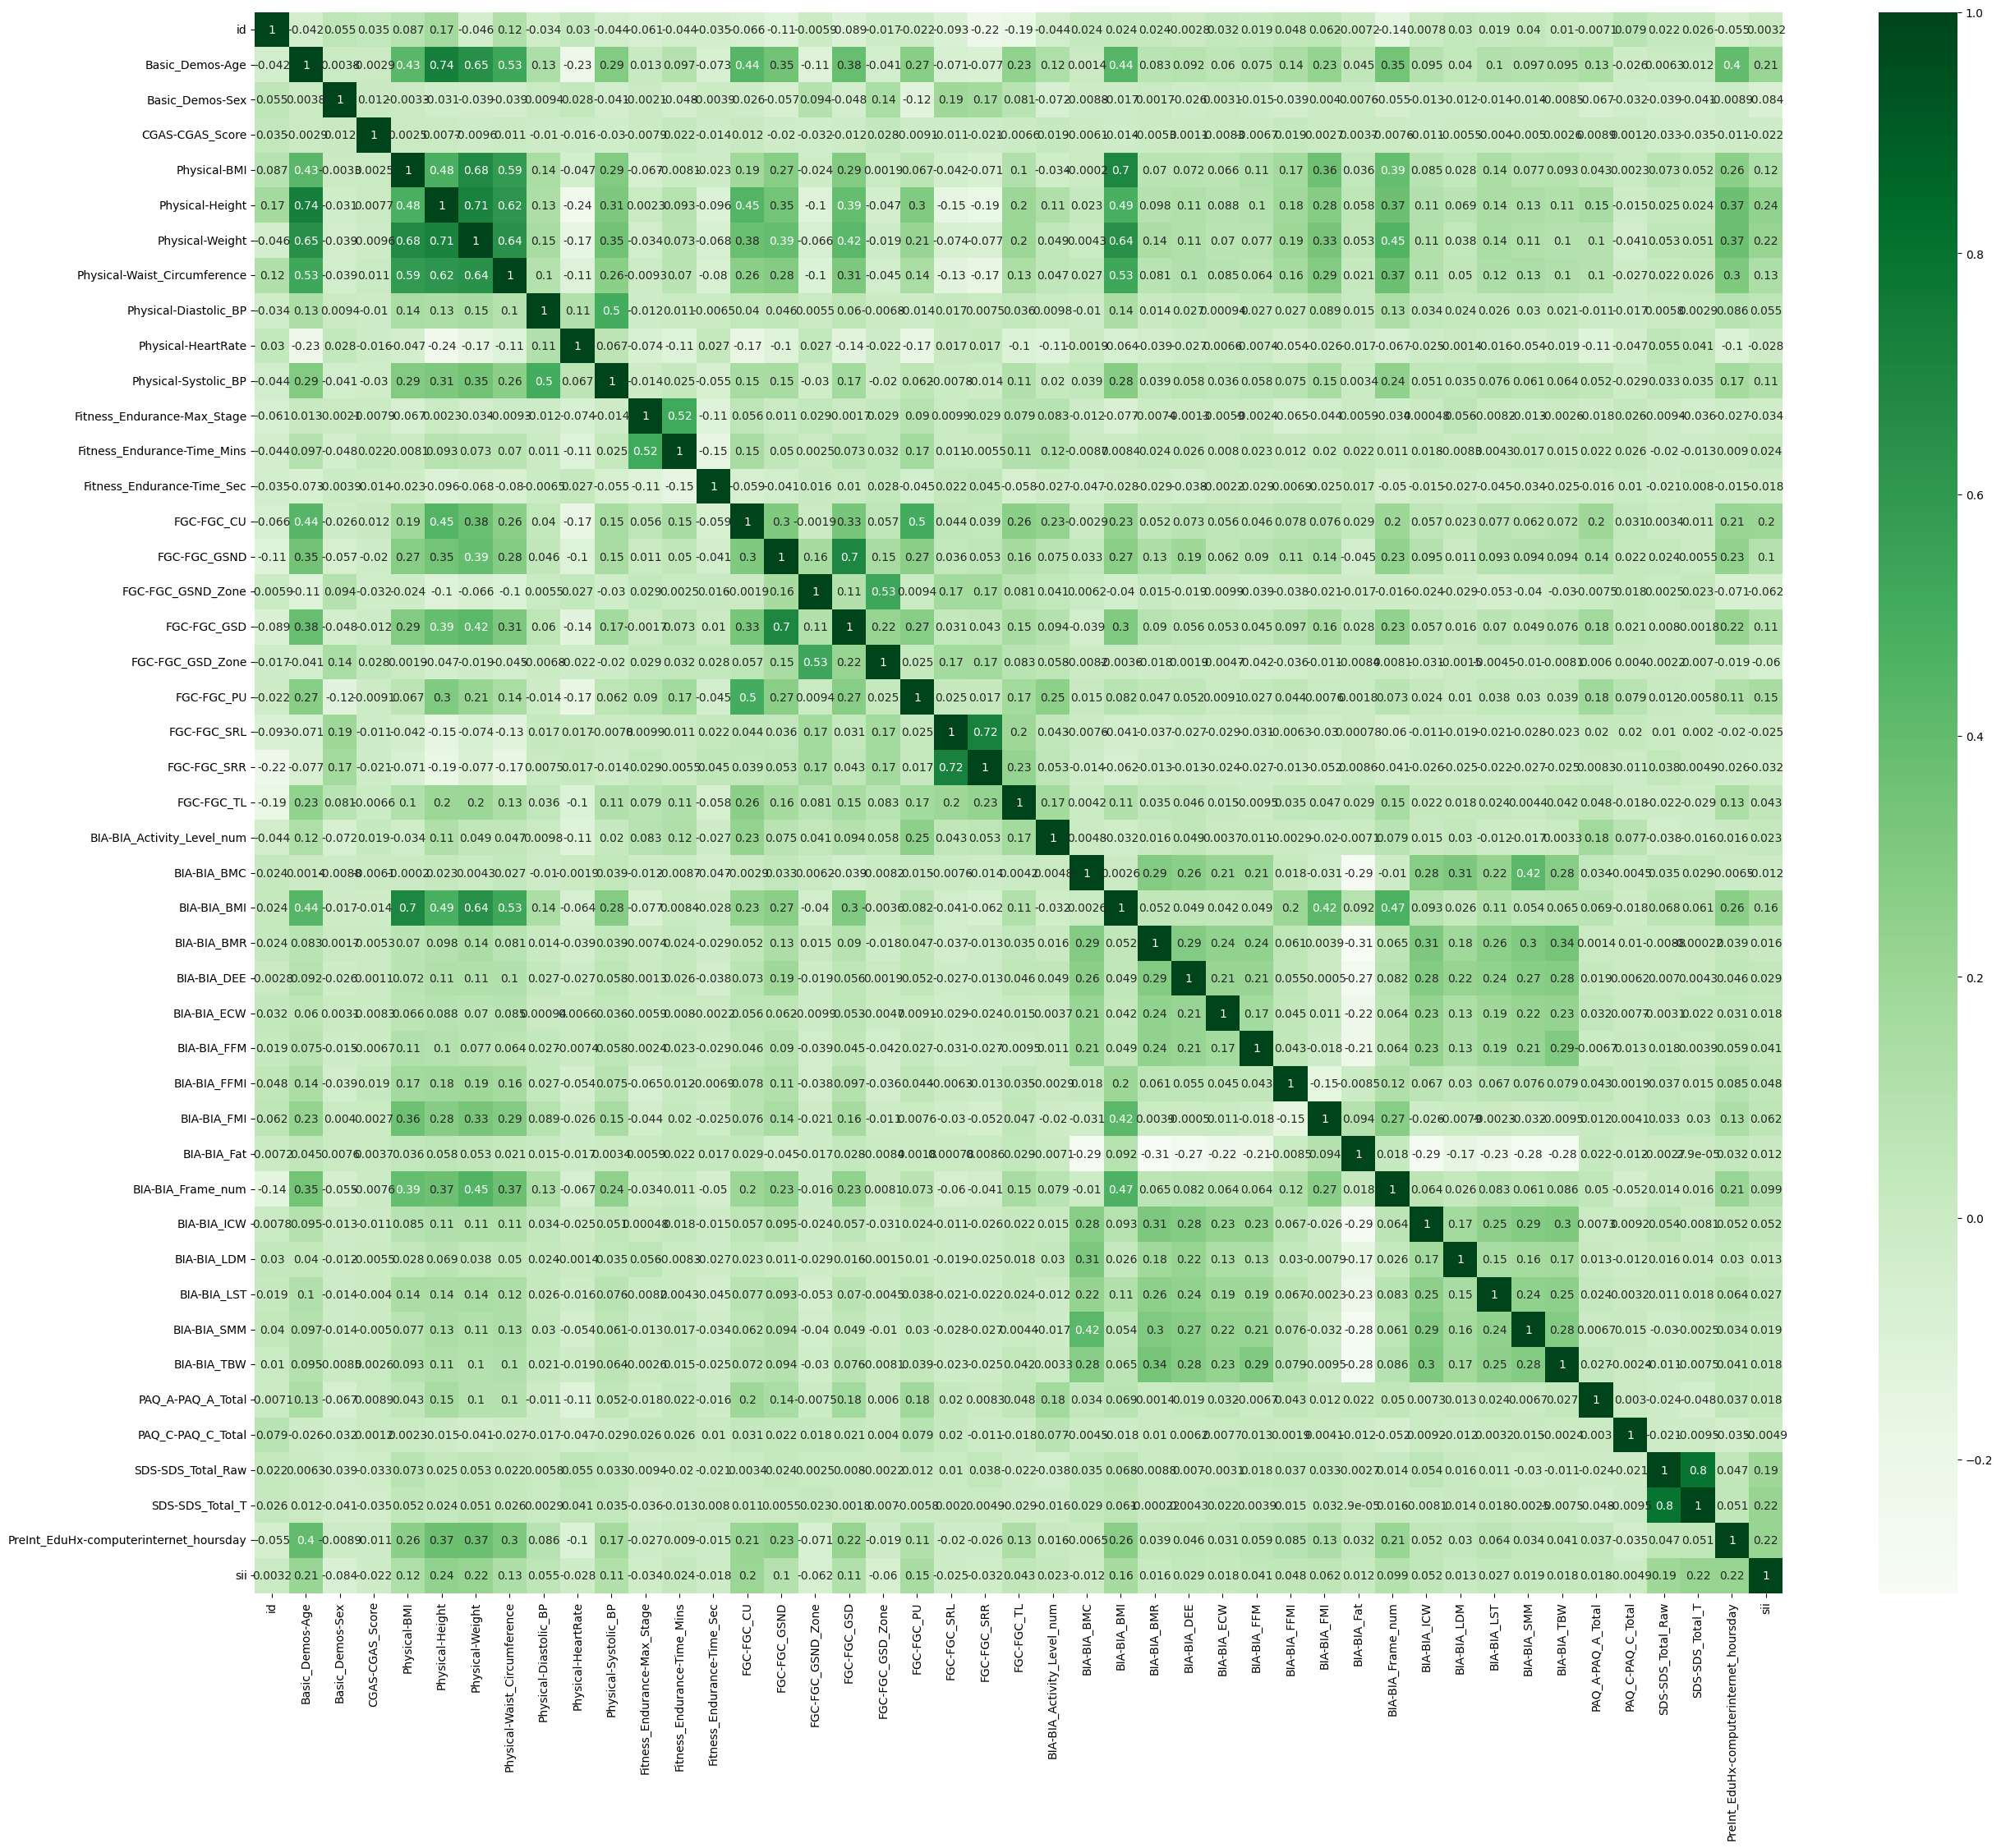

In [4]:
plt.figure(figsize=(30, 25))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), cmap="Greens", annot=True)
plt.show()

In [5]:
df["SDS-SDS_Total_T"].describe()

count    8460.000000
mean       57.148212
std         9.660587
min        38.000000
25%        54.223712
50%        55.500000
75%        58.000000
max       100.000000
Name: SDS-SDS_Total_T, dtype: float64

In [6]:
df["SDS-SDS_Total_Raw"].describe()

count    8460.000000
mean       40.793087
std         7.286205
min        17.000000
25%        38.500000
50%        39.863110
75%        41.500000
max        96.000000
Name: SDS-SDS_Total_Raw, dtype: float64

In [7]:
# Si rimuove SDS-SDS_Total_Raw perché ha correlazione 0.8 con SDS-SDS_Total_T ma è più grezzo
df.drop(["SDS-SDS_Total_Raw"], inplace=True, axis=1)

In [8]:
df.columns

Index(['id', 'Basic_Demos-Enroll_Season', 'Basic_Demos-Age', 'Basic_Demos-Sex',
       'CGAS-Season', 'CGAS-CGAS_Score', 'Physical-Season', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference',
       'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
       'Fitness_Endurance-Season', 'Fitness_Endurance-Max_Stage',
       'Fitness_Endurance-Time_Mins', 'Fitness_Endurance-Time_Sec',
       'FGC-Season', 'FGC-FGC_CU', 'FGC-FGC_GSND', 'FGC-FGC_GSND_Zone',
       'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone', 'FGC-FGC_PU', 'FGC-FGC_SRL',
       'FGC-FGC_SRR', 'FGC-FGC_TL', 'BIA-Season', 'BIA-BIA_Activity_Level_num',
       'BIA-BIA_BMC', 'BIA-BIA_BMI', 'BIA-BIA_BMR', 'BIA-BIA_DEE',
       'BIA-BIA_ECW', 'BIA-BIA_FFM', 'BIA-BIA_FFMI', 'BIA-BIA_FMI',
       'BIA-BIA_Fat', 'BIA-BIA_Frame_num', 'BIA-BIA_ICW', 'BIA-BIA_LDM',
       'BIA-BIA_LST', 'BIA-BIA_SMM', 'BIA-BIA_TBW', 'PAQ_A-Season',
       'PAQ_A-PAQ_A_Total', 'PAQ_C-Season', 'PAQ_C-PAQ_C

### PCA on the Physical Columns : Physical-BMI, Physical-Height, Physical-Weight, Physical-Waist_Circumference

In [9]:
physical_cols = ['Physical-BMI', 'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference']
physical_df = df[physical_cols]

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Standardize the data (Mean=0, Variance=1)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(physical_df)

In [11]:
# 2. Initialize and fit PCA
pca = PCA(n_components=2) # Reducing from 4 columns to 2
pca_data = pca.fit_transform(scaled_data)

# 3. Create a new DataFrame with the principal components
pca_df = pd.DataFrame(data=pca_data, columns=['Body_Mass_Index_Global', 'Body_Proportion'])
pca_df

,Body_Mass_Index_Global,Body_Proportion
0,-1.623486,0.612140
1,-2.431856,0.024275
2,-0.540879,-0.398740
3,-0.366886,-0.075267
4,-0.213769,-0.467040
...,...,...
8455,-2.265354,0.545182
8456,-0.539854,-0.240232
8457,1.910956,4.240239
8458,1.575919,-0.204200


In [12]:
pca.explained_variance_ratio_

array([0.71699609, 0.12991894])

In [13]:
pca.components_

array([[ 0.47715609,  0.49207147,  0.53217718,  0.49696598],
       [ 0.75715651, -0.6502093 , -0.02317761, -0.05834967]])

In [14]:
# Remove them four columns from the dataframe
df.drop(physical_cols, inplace=True, axis=1)
df.shape

(8460, 50)

In [15]:
# Add the two columns created using PCA above
df = pd.concat([df, pca_df], axis=1)
df.shape

(8460, 52)

### Aggiornamento matrice di correlazione

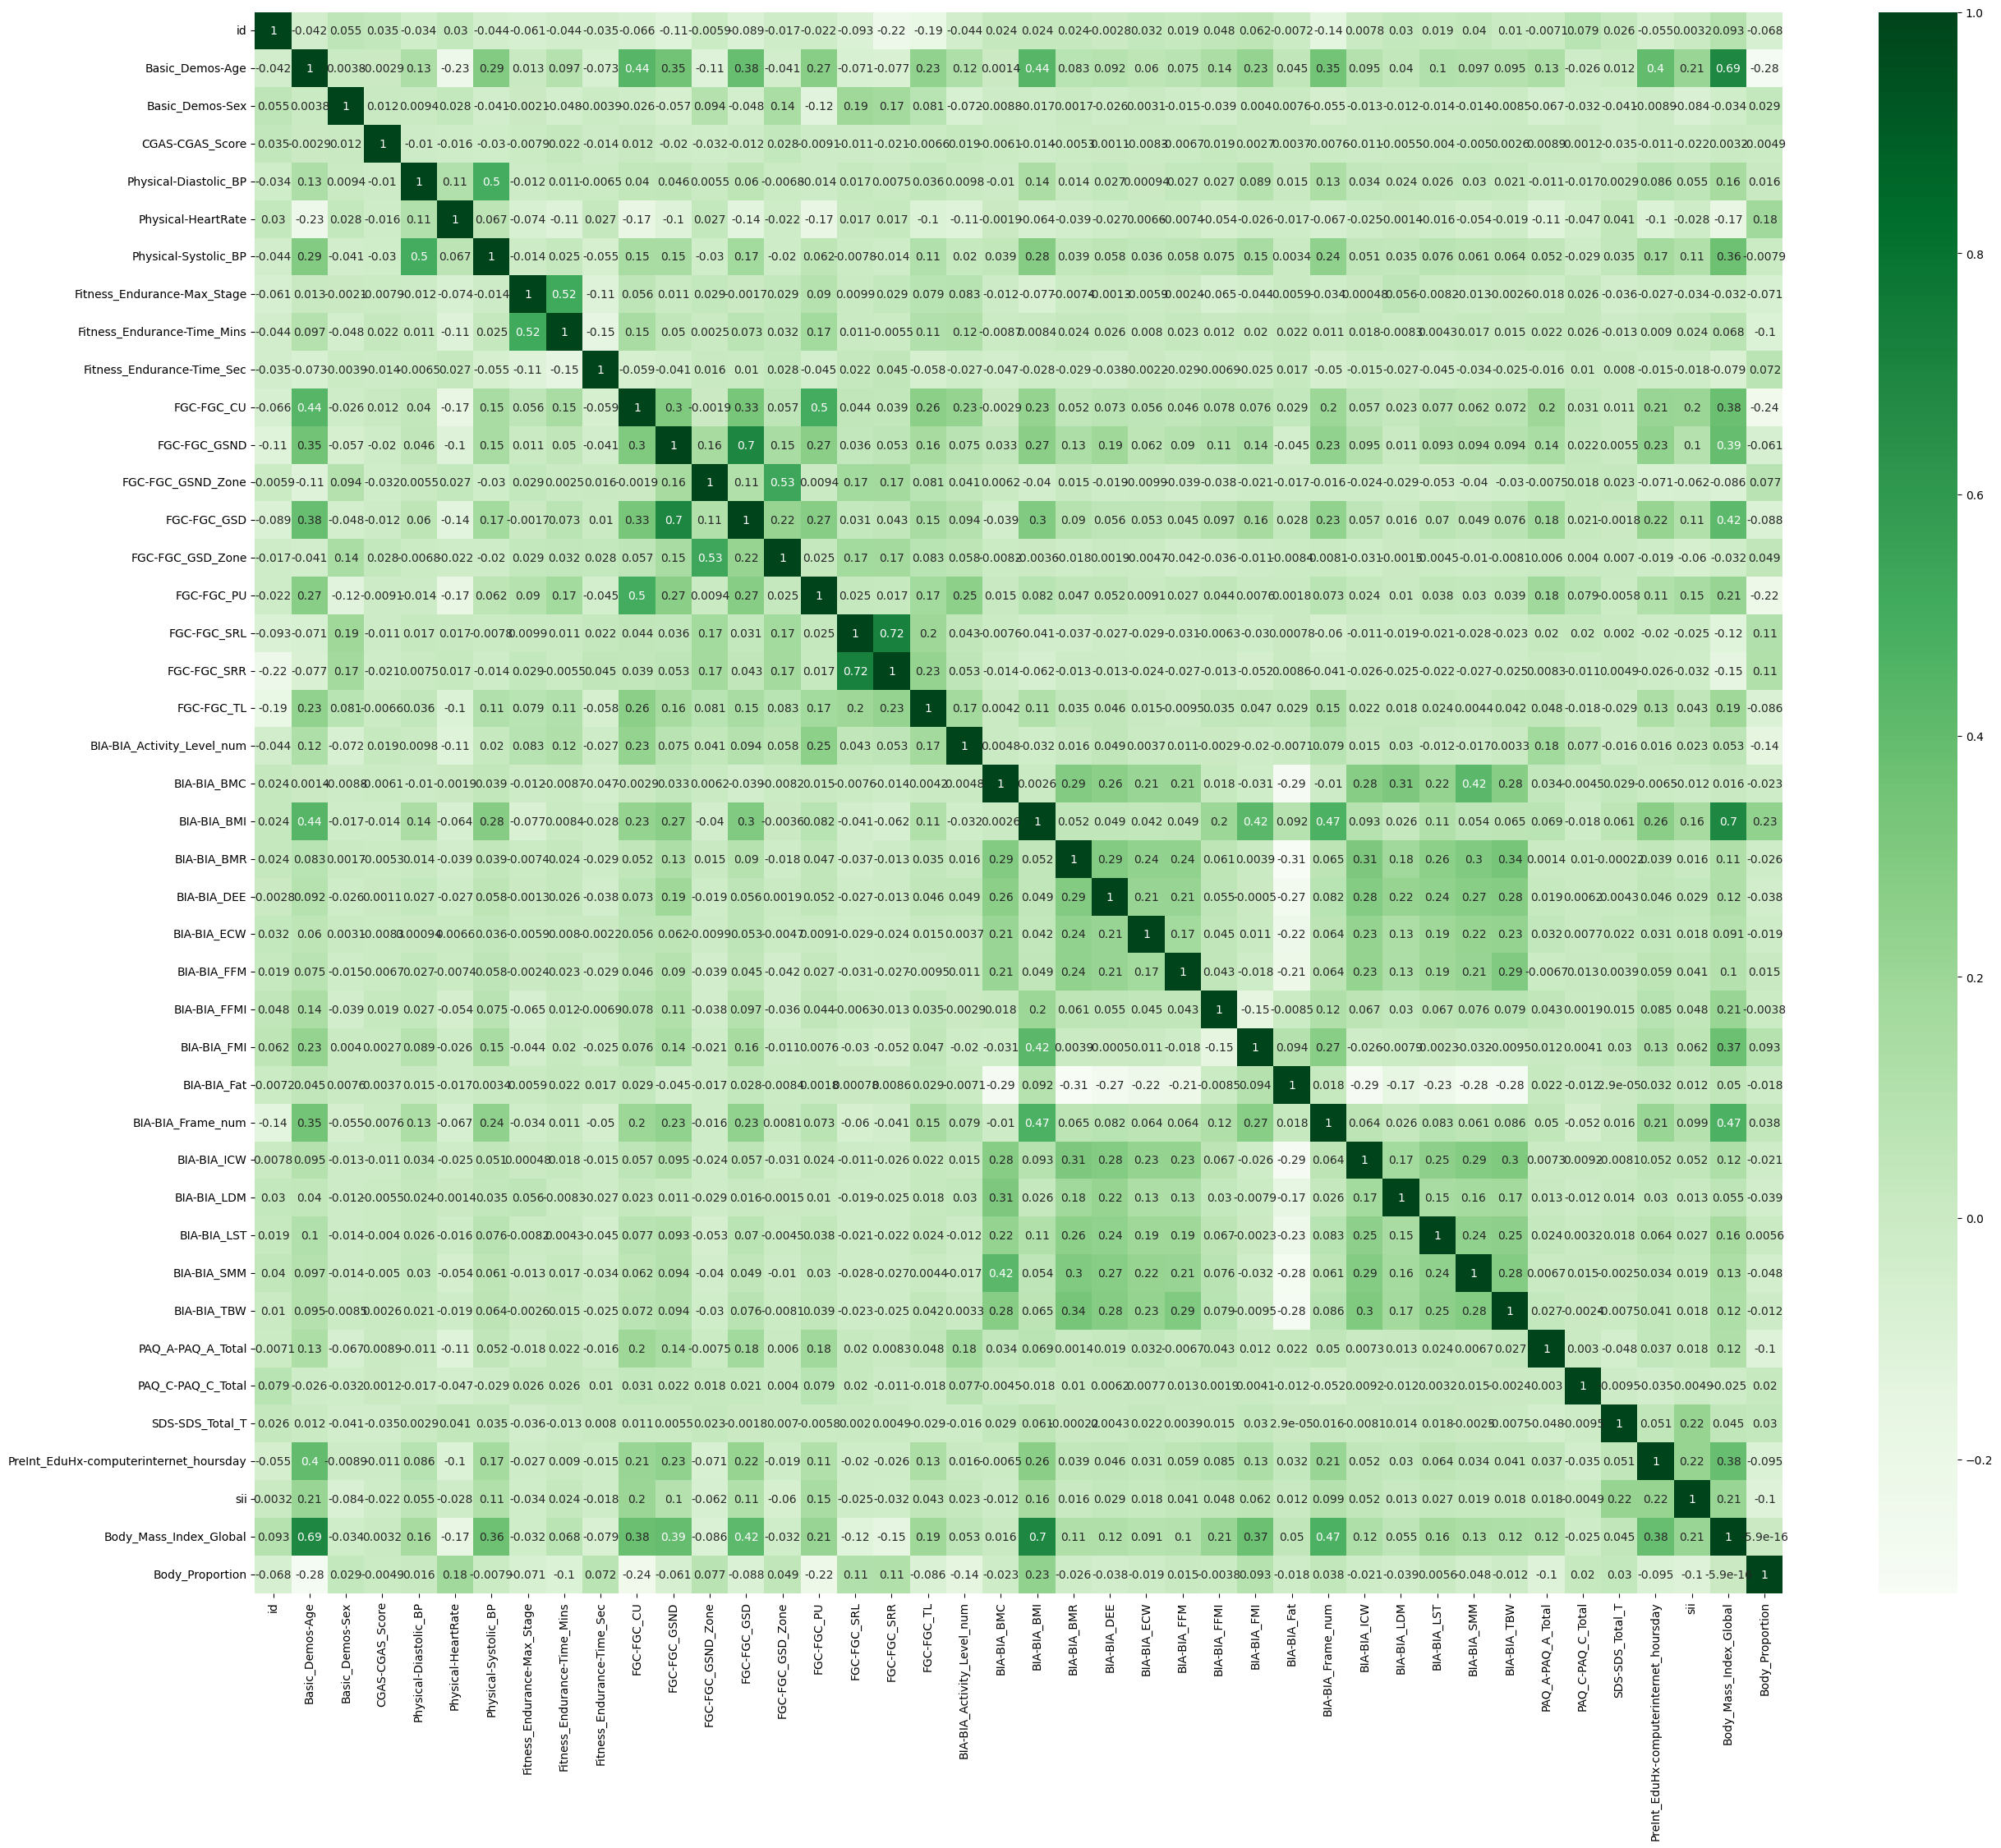

In [16]:
plt.figure(figsize=(30, 25))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), cmap="Greens", annot=True)
plt.show()

### We are going to take the average of FGC-FGC_SRL and FGC-FGC_SRR columns into a new column and remove them

In [17]:
df["FGC-FGC_SR"] = ( df["FGC-FGC_SRL"] + df["FGC-FGC_SRR"] ) / 2
df["FGC-FGC_SR"]

0        6.500000
1       11.000000
2       10.000000
3        7.000000
4        8.964158
          ...    
8455     7.000000
8456     5.000000
8457     9.500000
8458    10.500000
8459     7.000000
Name: FGC-FGC_SR, Length: 8460, dtype: float64

In [18]:
df.drop(["FGC-FGC_SRR", "FGC-FGC_SRL"], axis=1, inplace=True)
df.shape

(8460, 51)

### Drop di Id

In [19]:
df.drop(["id"], axis=1, inplace=True)
df.shape

(8460, 50)

### Creazione Fitness_Endurance-Time

In [20]:
df["Fitness_Endurance-Time"] =  df["Fitness_Endurance-Time_Sec"] + df["Fitness_Endurance-Time_Mins"] * 60
df["Fitness_Endurance-Time"].describe()

count    8460.000000
mean      448.811718
std        85.355791
min         5.000000
25%       436.709626
50%       448.431833
75%       477.500000
max      1200.000000
Name: Fitness_Endurance-Time, dtype: float64

In [21]:
df.drop(["Fitness_Endurance-Time_Sec", "Fitness_Endurance-Time_Mins"], axis=1, inplace=True)
df.shape

(8460, 49)

### Lets see if the several zone columns have something interesting

5776
(8460, 49)


,FGC-FGC_GSND_Zone
count,2684.000000
mean,1.952028
std,0.132224
min,0.915408
25%,1.919571
50%,1.969010
75%,2.011296
max,2.575107


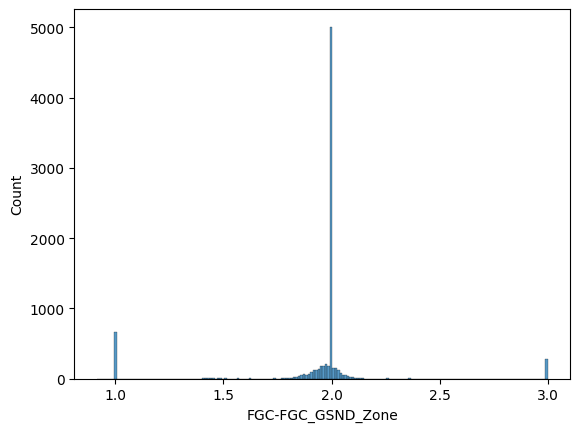

In [31]:
sns.histplot(df["FGC-FGC_GSND_Zone"])
print(df["FGC-FGC_GSND_Zone"].isin(values=[1, 2, 3]).sum())
print(df.shape)

imputed_vals = df.loc[~df["FGC-FGC_GSND_Zone"].isin(values=[1, 2, 3]),["FGC-FGC_GSND_Zone"]]
imputed_vals.describe()

### Colonne Grip Strength
Facciamo drop delle colonne binarie perché hanno valori che tecnicamente dovrebbero essere impossibili

In [ ]:
df["FGC-FGC_GSD"].describe()

count    8460.000000
mean       20.849418
std         6.520553
min        -8.929237
25%        18.750000
50%        20.019667
75%        21.200000
max       123.800000
Name: FGC-FGC_GSD, dtype: float64

In [ ]:
xyz = df.loc[df["FGC-FGC_GSND_Zone"] == 1,["FGC-FGC_GSND", "FGC-FGC_GSND_Zone"]]
xyz["FGC-FGC_GSND"].describe()


count    666.000000
mean      18.456521
std        8.033765
min        0.000000
25%       13.025000
50%       16.750811
75%       23.000000
max       81.400000
Name: FGC-FGC_GSND, dtype: float64

In [ ]:
xyz = df.loc[df["FGC-FGC_GSND_Zone"] == 2,["FGC-FGC_GSND", "FGC-FGC_GSND_Zone"]]
xyz["FGC-FGC_GSND"].describe()

count    4828.000000
mean       19.572069
std         6.802816
min         0.000000
25%        17.300000
50%        18.341542
75%        20.050000
max       124.000000
Name: FGC-FGC_GSND, dtype: float64

In [ ]:
xyz = df.loc[df["FGC-FGC_GSND_Zone"] == 3,["FGC-FGC_GSND", "FGC-FGC_GSND_Zone"]]
xyz["FGC-FGC_GSND"].describe()


count    282.000000
mean      26.297156
std       10.290585
min        0.000000
25%       20.912819
50%       24.300000
75%       30.600000
max       81.800000
Name: FGC-FGC_GSND, dtype: float64

<Axes: xlabel='FGC-FGC_GSND_Zone', ylabel='Count'>

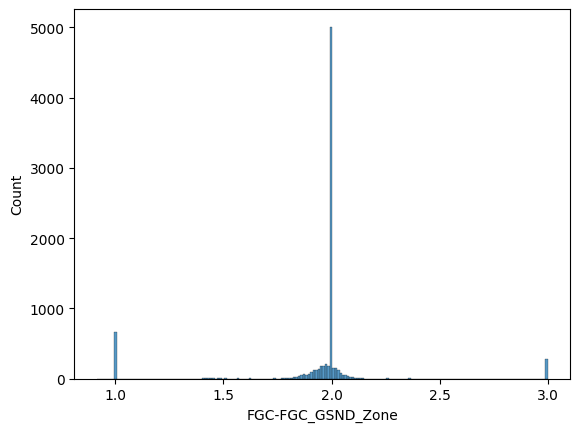

In [ ]:
sns.histplot(df["FGC-FGC_GSND_Zone"])

In [ ]:
df["FGC-FGC_GSND_Zone"].value_counts()

FGC-FGC_GSND_Zone
2.000000    4828
1.000000     666
3.000000     282
1.884255       1
1.939834       1
            ... 
2.369145       1
1.919031       1
2.088148       1
1.936487       1
1.937887       1
Name: count, Length: 2687, dtype: int64

In [ ]:
df.drop(["FGC-FGC_GSND_Zone", "FGC-FGC_GSD_Zone"], axis=1, inplace=True)
df.shape

### Drop di BIA-BIA_Activity_Level_num perché ha valori impossibili

In [ ]:
sns.histplot(df["BIA-BIA_Activity_Level_num"])

KeyError: 'BIA-BIA_Activity_Level_num'

In [ ]:
df.drop(["BIA-BIA_Activity_Level_num"], axis=1, inplace=True)
df.shape

(8460, 46)